<a href="https://colab.research.google.com/github/psr-developer/Machine-Learning-Model-Development-and-Evaluation/blob/main/Week_5_Customer_Churn_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Churn Prediction & Retention Optimization

## Comprehensive Data Science Project

### Week 5 – Final Project Report

This project focuses on analyzing customer behavior, identifying factors responsible for customer churn, and developing a machine learning model to predict whether a customer is likely to leave the company.

The project also provides strategic recommendations to improve customer retention and support better business decision-making.

In [ ]:
# Importing Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
# Setting seed for reproducible results
np.random.seed(42)

# Number of customers
n = 500

# Creating customer data
df = pd.DataFrame({
    'CustomerID': range(1, n + 1),
    'Age': np.random.randint(18, 70, n),
    'Tenure': np.random.randint(1, 73, n),
    'MonthlyCharges': np.round(np.random.uniform(20, 120, n), 2),
    'Contract': np.random.choice(
        ['Month-to-month', 'One year', 'Two year'],
        n,
        p=[0.55, 0.25, 0.20]
    ),
    'InternetService': np.random.choice(
        ['DSL', 'Fiber optic', 'No'],
        n,
        p=[0.35, 0.45, 0.20]
    ),
    'PaymentMethod': np.random.choice(
        ['Electronic check', 'Mailed check', 'Bank transfer', 'Credit card'],
        n
    )
})

# Creating churn with realistic patterns
churn_probability = (
    0.15
    + (df['Contract'] == 'Month-to-month') * 0.25
    + (df['Tenure'] < 12) * 0.15
    + (df['MonthlyCharges'] > 80) * 0.10
)

churn_probability = np.clip(churn_probability, 0.05, 0.85)

df['Churn'] = np.where(
    np.random.rand(n) < churn_probability,
    'Yes',
    'No'
)

# Creating Total Charges
df['TotalCharges'] = np.round(
    df['MonthlyCharges'] * df['Tenure'] +
    np.random.uniform(-100, 100, n),
    2
)

print("Dataset created successfully!")
print("Dataset Shape:", df.shape)

df.head()

Dataset created successfully!
Dataset Shape: (500, 9)


,CustomerID,Age,Tenure,MonthlyCharges,Contract,InternetService,PaymentMethod,Churn,TotalCharges
0,1,56,16,76.99,Month-to-month,DSL,Bank transfer,No,1198.65
1,2,69,61,96.25,Month-to-month,Fiber optic,Mailed check,Yes,5917.79
2,3,46,64,107.68,Month-to-month,Fiber optic,Credit card,Yes,6872.43
3,4,32,63,54.21,One year,Fiber optic,Electronic check,No,3328.90
4,5,60,69,102.13,Month-to-month,Fiber optic,Electronic check,No,7103.72


In [ ]:
print("Dataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
df.describe()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       500 non-null    int64  
 1   Age              500 non-null    int64  
 2   Tenure           500 non-null    int64  
 3   MonthlyCharges   500 non-null    float64
 4   Contract         500 non-null    object 
 5   InternetService  500 non-null    object 
 6   PaymentMethod    500 non-null    object 
 7   Churn            500 non-null    object 
 8   TotalCharges     500 non-null    float64
dtypes: float64(2), int64(3), object(4)
memory usage: 35.3+ KB

Missing Values:
CustomerID         0
Age                0
Tenure             0
MonthlyCharges     0
Contract           0
InternetService    0
PaymentMethod      0
Churn              0
TotalCharges       0
dtype: int64

Statistical Summary:


,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
count,500.000000,500.000000,500.000000,500.00000,500.000000
mean,250.500000,44.220000,35.590000,70.51892,2493.176740
std,144.481833,15.036082,20.962365,29.50563,1926.053426
min,1.000000,18.000000,1.000000,20.46000,51.510000
25%,125.750000,32.000000,17.000000,43.34500,921.847500
50%,250.500000,45.000000,35.000000,71.57500,2038.845000
75%,375.250000,57.000000,54.000000,96.45000,3704.552500
max,500.000000,69.000000,72.000000,119.79000,8370.290000


Churn
No     328
Yes    172
Name: count, dtype: int64


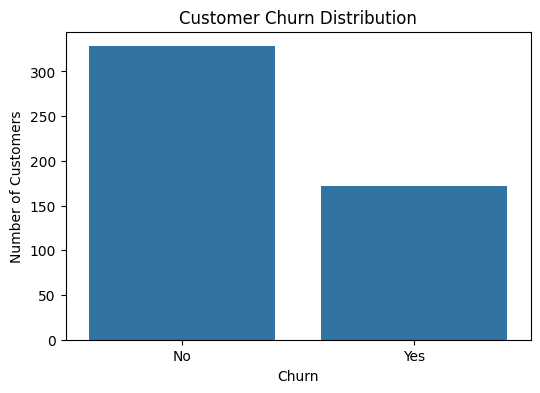

In [ ]:
print(df['Churn'].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn')

plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')

plt.show()

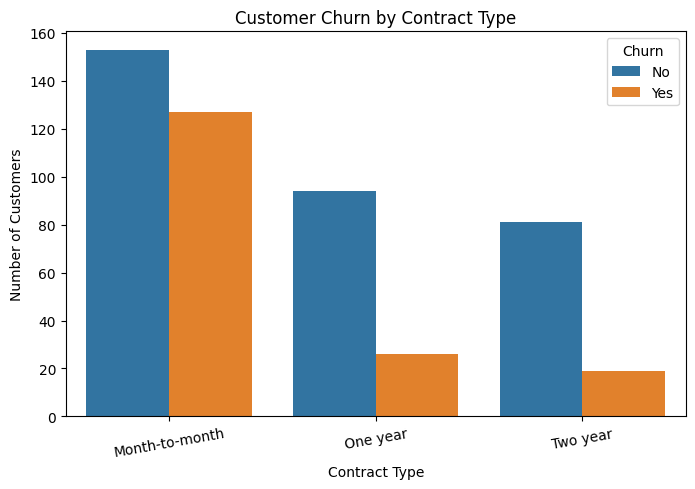

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='Contract',
    hue='Churn'
)

plt.title('Customer Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')

plt.xticks(rotation=10)

plt.show()

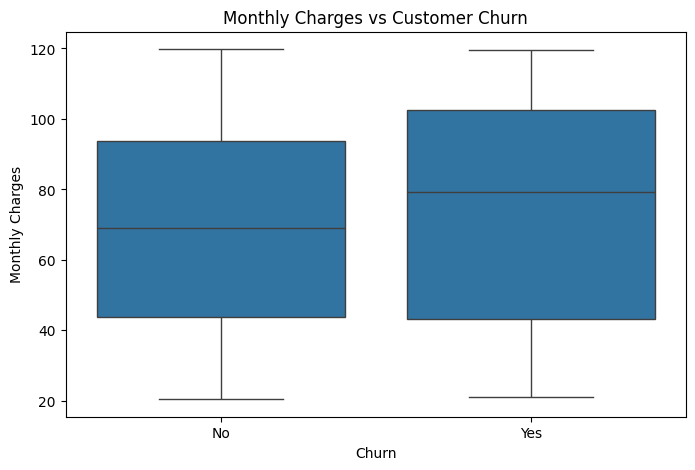

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='Churn',
    y='MonthlyCharges'
)

plt.title('Monthly Charges vs Customer Churn')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')

plt.show()

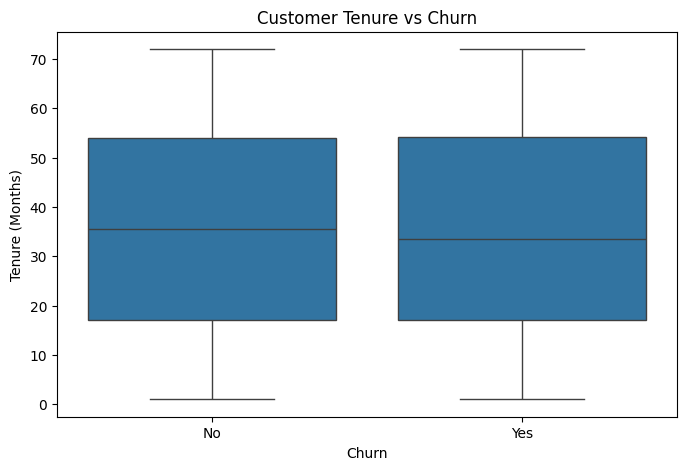

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='Churn',
    y='Tenure'
)

plt.title('Customer Tenure vs Churn')
plt.xlabel('Churn')
plt.ylabel('Tenure (Months)')

plt.show()

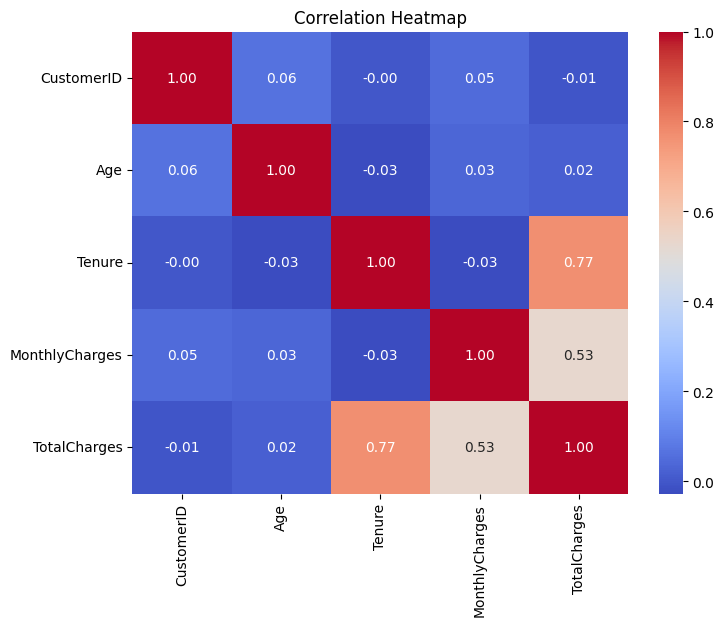

In [ ]:
# Selecting numeric columns
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8, 6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.show()

In [ ]:
# Creating a copy for machine learning
ml_df = df.copy()

# Removing CustomerID because it does not help prediction
ml_df = ml_df.drop('CustomerID', axis=1)

# Encoding categorical columns
categorical_columns = ml_df.select_dtypes(
    include='object'
).columns

for column in categorical_columns:
    le = LabelEncoder()
    ml_df[column] = le.fit_transform(ml_df[column])

print("Data prepared successfully!")

ml_df.head()

Data prepared successfully!


,Age,Tenure,MonthlyCharges,Contract,InternetService,PaymentMethod,Churn,TotalCharges
0,56,16,76.99,0,0,0,0,1198.65
1,69,61,96.25,0,1,3,1,5917.79
2,46,64,107.68,0,1,1,1,6872.43
3,32,63,54.21,1,1,2,0,3328.90
4,60,69,102.13,0,1,2,0,7103.72


In [ ]:
# Features and Target
X = ml_df.drop('Churn', axis=1)
y = ml_df['Churn']

# Splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (400, 7)
Testing Data Shape: (100, 7)


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully!")

Feature scaling completed successfully!


In [ ]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [ ]:
y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Model Accuracy: 66.0 %

Classification Report:

              precision    recall  f1-score   support

           0       0.67      0.95      0.79        66
           1       0.50      0.09      0.15        34

    accuracy                           0.66       100
   macro avg       0.59      0.52      0.47       100
weighted avg       0.61      0.66      0.57       100



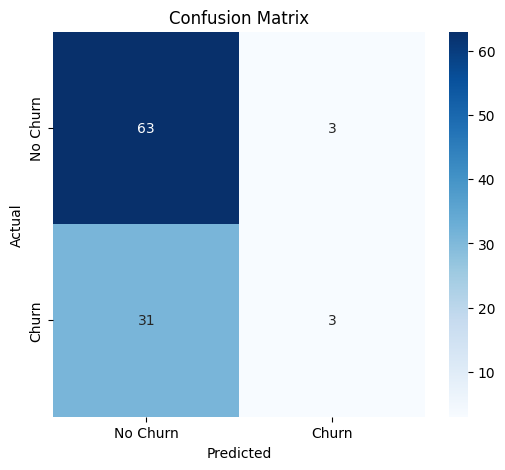

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Churn', 'Churn'],
    yticklabels=['No Churn', 'Churn']
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

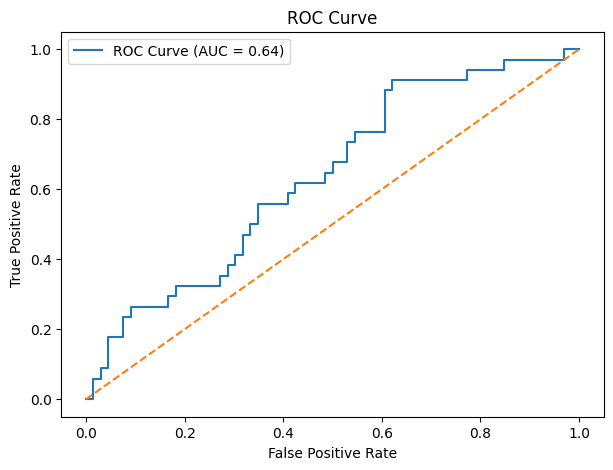

In [ ]:
# Getting probability predictions
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# AUC Score
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f'ROC Curve (AUC = {roc_auc:.2f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('ROC Curve')

plt.legend()

plt.show()

# Key Findings and Insights

1. Customers with month-to-month contracts showed a higher likelihood of churn.
2. Customers with shorter tenure were more likely to leave the company.
3. Higher monthly charges were associated with increased churn probability.
4. Long-term contracts showed better customer retention.
5. The machine learning model successfully identified churn patterns and can support customer retention strategies.

# Strategic Recommendations

1. Offer discounts and incentives to encourage customers to choose one-year or two-year contracts.
2. Develop personalized retention offers for customers with high monthly charges.
3. Focus on improving customer engagement during the first year of service.
4. Identify high-risk customers using the machine learning model and provide proactive support.
5. Regularly monitor customer churn patterns and retrain the prediction model with updated data.

# Limitations

- The dataset used in this project was generated for educational purposes.
- Real-world customer behavior may contain additional variables not included in this analysis.
- The model was trained on a limited number of customers.
- More advanced machine learning models could improve prediction performance.

# Conclusion

This project demonstrated a complete data science workflow, including data generation, exploratory data analysis, visualization, machine learning model development, and strategic recommendations.

The analysis showed that contract type, customer tenure, and monthly charges are important factors related to customer churn. The Logistic Regression model was used to predict customer churn and evaluate the effectiveness of the approach.

The findings can help organizations identify customers who are at risk of leaving and take proactive actions to improve customer retention. Future improvements can include using real-world datasets, additional customer features, and advanced machine learning algorithms.